<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Fundamentos_em_Ciencias_de_Dados_Aula_13_M%C3%A9tricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métricas de Desempenho em Modelos Supervisionados

## 5500004 Fundamentos em Ciências de Dados

## Profa. Cibele Russo - ICMC USP

Fonte: MOREIRA, João Mendes; CARVALHO, André C. P. L. F. de; HORVÁTH, Tomáš. **A General Introduction to Data Analytics**. 1. ed. Hoboken, NJ: John Wiley & Sons, Inc., 2019.

Notebook criado com apoio de ferramentas da IA generativa: NotebookLM e ChatGPT.

Dados utilizados neste notebook: bases de exemplo disponíveis no pacote `scikit-learn`.


# Métricas de Desempenho em Modelos Supervisionados

Como avaliar se um modelo **aprendeu** corretamente os padrões dos dados de treinamento e como ele se comporta diante de dados novos, em uma amostra de teste?

A avaliação depende do tipo de tarefa preditiva:

- **Classificação:** a resposta é qualitativa, como `positivo/negativo`, `sim/não`, `fraude/não fraude`.
- **Regressão:** a resposta é quantitativa, como preço, salário, consumo, tempo ou quantidade.

Vamos calcular métricas de desempenho para os dois cenários.


## 1. Biblioteca scikit-learn (módulo metrics)

Vamos carregar bibliotecas para manipulação de dados, visualização, modelagem e cálculo das métricas.


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# Configurações gerais
sns.set_theme(style="whitegrid")
sns.set_style("white")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13

RANDOM_STATE = 42


# 2. Métricas para Modelos de Classificação

Na classificação binária, o objetivo é atribuir cada objeto a uma de duas classes.

Exemplos comuns:

- cliente inadimplente ou adimplente;
- exame positivo ou negativo;
- transação fraudulenta ou não fraudulenta;
- cliente que cancela ou não cancela um serviço.

Neste exemplo, vamos usar a base `breast_cancer`, disponível no `scikit-learn`, apenas para fins didáticos.


## 2.1. Leitura dos dados de classificação

A variável resposta possui duas classes. Para este notebook, vamos considerar a classe `1` como a classe positiva.


### Conjunto de Dados: Breast Cancer Wisconsin Diagnostic

O conjunto de dados **Breast Cancer Wisconsin Diagnostic**, disponibilizado pela biblioteca `scikit-learn`, é utilizado em problemas de classificação supervisionada para prever se um tumor de mama é **maligno** ou **benigno** a partir de características extraídas de imagens digitalizadas de aspirados por agulha fina (Fine Needle Aspiration - FNA).

#### Características gerais

| Característica | Valor |
|---------------|--------|
| Número de amostras | 569 |
| Número de atributos preditores | 30 |
| Tipo de problema | Classificação binária |
| Variável alvo | Diagnóstico do tumor |
| Classes | 0 = Maligno, 1 = Benigno |
| Biblioteca | `sklearn.datasets.load_breast_cancer()` |

#### Descrição dos atributos

As 30 variáveis correspondem a estatísticas calculadas a partir de características dos núcleos celulares observados nas imagens. Essas características são agrupadas em três categorias:

| Grupo | Descrição |
|---------|-----------|
| `mean` | Valor médio da característica |
| `error` | Erro padrão da característica |
| `worst` | Maior valor observado da característica |

As características medidas são:

| Característica | Descrição |
|---------------|-----------|
| `radius` | Distância média do centro à borda |
| `texture` | Variação dos níveis de cinza |
| `perimeter` | Perímetro do núcleo celular |
| `area` | Área do núcleo celular |
| `smoothness` | Variação local dos comprimentos dos raios |
| `compactness` | Relação entre perímetro e área |
| `concavity` | Severidade das porções côncavas do contorno |
| `concave points` | Número de pontos côncavos do contorno |
| `symmetry` | Simetria do núcleo celular |
| `fractal dimension` | Aproximação da dimensão fractal do contorno |

Cada uma dessas dez características possui as versões `mean`, `error` e `worst`, totalizando 30 atributos preditores.

#### Variável alvo

| Valor | Classe |
|--------|---------|
| 0 | Maligno |
| 1 | Benigno |

#### Observações

- O conjunto de dados contém informações de 569 pacientes.
- As classes apresentam leve desbalanceamento, com maior quantidade de tumores benignos.
- Trata-se de um dos conjuntos de dados mais utilizados para avaliação de algoritmos de classificação binária.
- As variáveis são numéricas e representam medidas morfológicas dos núcleos celulares extraídas de imagens médicas.

In [2]:
cancer = load_breast_cancer(as_frame=True)

df_clf = cancer.frame.copy()
df_clf.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dimensões da base:", df_clf.shape)
print("Classes:", cancer.target_names)

df_clf["target"].value_counts().rename(index={0: cancer.target_names[0], 1: cancer.target_names[1]})


Dimensões da base: (569, 31)
Classes: ['malignant' 'benign']


,count
target,
benign,357
malignant,212


## 2.2. Separação em treinamento e teste

A separação entre treinamento e teste permite avaliar o modelo em dados que não foram usados para o ajuste.


In [4]:
X_clf = df_clf.drop(columns="target")
y_clf = df_clf["target"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Tamanho do treino:", X_train_clf.shape[0])
print("Tamanho do teste:", X_test_clf.shape[0])


Tamanho do treino: 426
Tamanho do teste: 143


## 2.3. Ajuste de um modelo de classificação

Vamos usar regressão logística com padronização das variáveis preditoras dentro de um `Pipeline`. A padronização é estimada apenas no conjunto de treinamento.


In [5]:
modelo_clf = Pipeline(steps=[
    ("padronizacao", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

modelo_clf.fit(X_train_clf, y_train_clf)

y_pred_clf = modelo_clf.predict(X_test_clf)
y_prob_clf = modelo_clf.predict_proba(X_test_clf)[:, 1]

y_pred_clf[:10]


array([1, 0, 1, 1, 0, 0, 0, 0, 0, 1])

## 2.4. A Matriz de Confusão

A **Matriz de Confusão** é uma tabela 2x2 que cruza as previsões do modelo com as classes reais.

Se a classe positiva for representada por `1`, seus componentes são:

- **Verdadeiros Positivos (TP):** o modelo previu positivo e a classe real era positiva.
- **Verdadeiros Negativos (TN):** o modelo previu negativo e a classe real era negativa.
- **Falsos Positivos (FP):** o modelo previu positivo, mas a classe real era negativa.
- **Falsos Negativos (FN):** o modelo previu negativo, mas a classe real era positiva.


| Classe Real \\ Classe Predita | Negativa | Positiva |
|-------------------------------|----------|----------|
| Negativa                      | TN       | FP       |
| Positiva                      | FN       | TP       |

Essa matriz é a base para várias métricas de classificação.


In [6]:
cm = confusion_matrix(y_test_clf, y_pred_clf)
cm


array([[52,  1],
       [ 1, 89]])

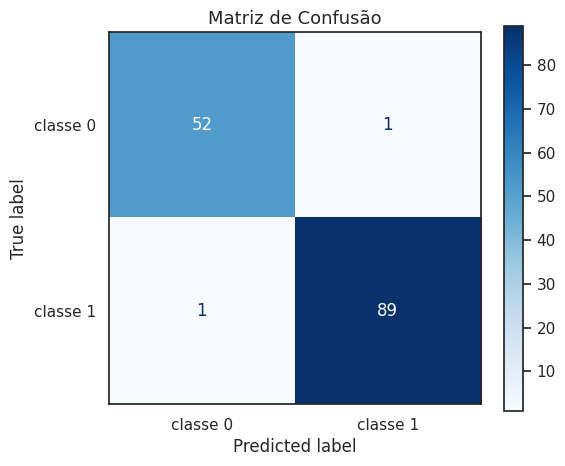

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_clf,
    y_pred_clf,
    display_labels=["classe 0", "classe 1"],
    cmap="Blues",
    values_format="d",
    ax=ax
)
ax.set_title("Matriz de Confusão")
plt.show()


In [8]:
tn, fp, fn, tp = cm.ravel()

print("TN - Verdadeiros Negativos:", tn)
print("FP - Falsos Positivos:", fp)
print("FN - Falsos Negativos:", fn)
print("TP - Verdadeiros Positivos:", tp)


TN - Verdadeiros Negativos: 52
FP - Falsos Positivos: 1
FN - Falsos Negativos: 1
TP - Verdadeiros Positivos: 89


## 2.5. Principais métricas de classificação

Com base na matriz de confusão, derivamos métricas importantes:

- **Acurácia:** proporção de acertos totais.

$$ACC = \frac{TP + TN}{TP + TN + FP + FN}$$

- **Precisão:** entre os casos previstos como positivos, proporção que realmente era positiva.

$$Precisão = \frac{TP}{TP + FP}$$

- **Revocação ou Recall:** entre os casos realmente positivos, proporção identificada corretamente. Também é chamada de **Sensibilidade**.

$$Recall = \frac{TP}{TP + FN}$$

- **F1-Score:** média harmônica entre precisão e recall.

$$F1 = 2 \cdot \frac{Precisão \cdot Recall}{Precisão + Recall}$$

- **AUC:** área sob a curva ROC. Mede a capacidade do modelo de ordenar observações positivas acima das negativas ao variar o limiar de classificação.


In [9]:
acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
auc = roc_auc_score(y_test_clf, y_prob_clf)

metricas_clf = pd.DataFrame({
    "Métrica": ["Acurácia", "Precisão", "Recall/Sensibilidade", "F1-Score", "AUC"],
    "Valor": [acc, prec, rec, f1, auc]
})

metricas_clf


,Métrica,Valor
0,Acurácia,0.986014
1,Precisão,0.988889
2,Recall/Sensibilidade,0.988889
3,F1-Score,0.988889
4,AUC,0.997694


## 2.6. Métricas adicionais para classificação

Algumas métricas são úteis quando as classes estão desbalanceadas ou quando desejamos avaliar o desempenho nas duas classes.

- **Especificidade:** proporção de negativos identificados corretamente.

$$\textbf{Especificidade} = \frac{TN}{TN + FP}$$

- **MCC (Coeficiente de Correlação de Matthews):** utiliza os quatro elementos da matriz de confusão e é informativa em dados desbalanceados.

- **G-Mean:** média geométrica entre sensibilidade e especificidade.

$$\textbf{G-Mean} = \sqrt{Sensibilidade \cdot Especificidade}$$


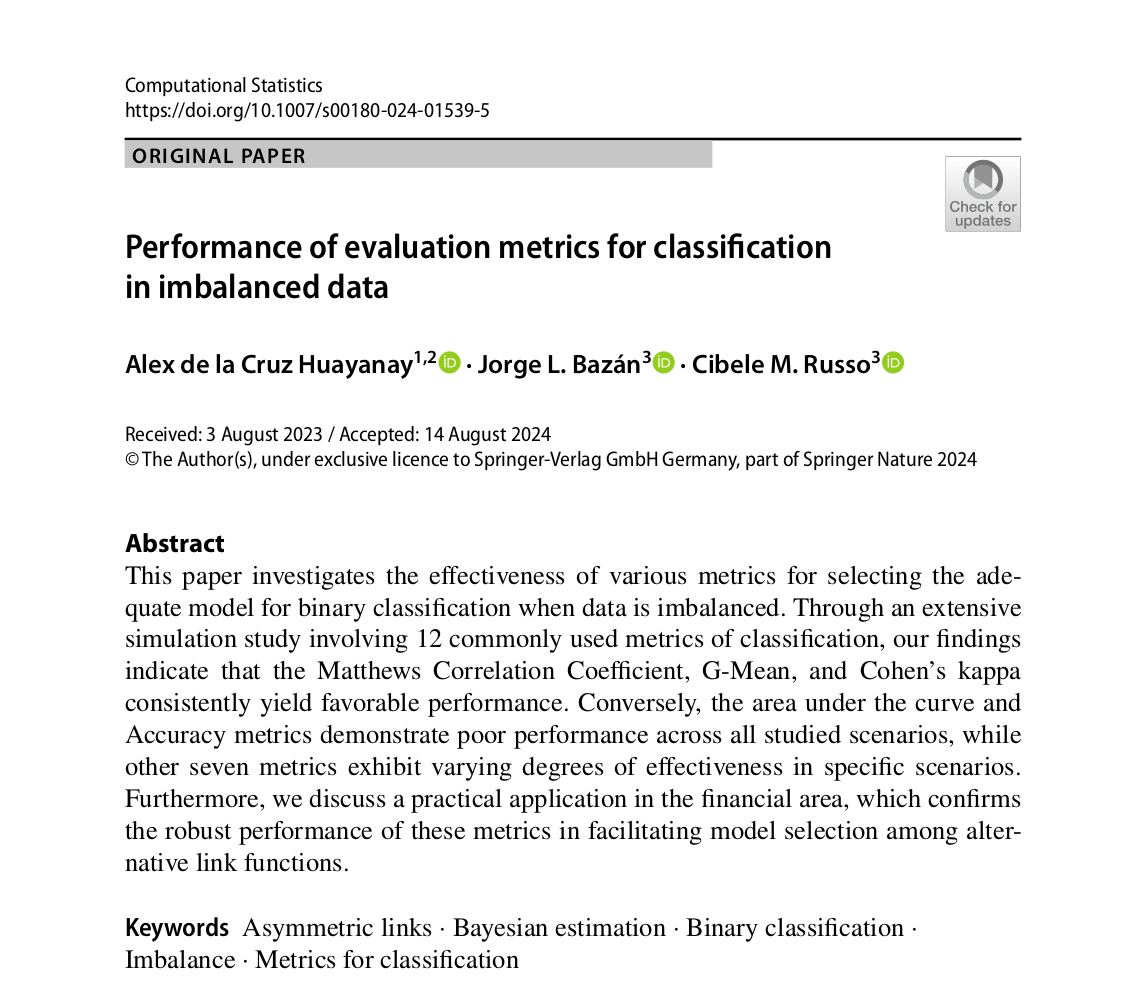

In [ ]:
especificidade = tn / (tn + fp)
mcc = matthews_corrcoef(y_test_clf, y_pred_clf)
g_mean = np.sqrt(rec * especificidade)

metricas_clf_extra = pd.DataFrame({
    "Métrica": ["Especificidade", "MCC", "G-Mean"],
    "Valor": [especificidade, mcc, g_mean]
})

metricas_clf_extra


## 2.7. Relatório de classificação

O `classification_report` mostra precisão, recall e F1-score por classe, além de médias agregadas.


In [ ]:
print(classification_report(y_test_clf, y_pred_clf, target_names=["classe 0", "classe 1"]))


## 2.8. Curva ROC

A curva ROC representa a relação entre:

- taxa de verdadeiros positivos, isto é, sensibilidade;
- taxa de falsos positivos, isto é, `1 - especificidade`.

Quanto maior a AUC, melhor a capacidade discriminativa do modelo.


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Classificador aleatório")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC")
ax.legend()
plt.show()


## 2.9. Efeito do limiar de classificação

Por padrão, muitos modelos classificam como positivo quando a probabilidade estimada é maior ou igual a 0,5.

Alterar esse limiar muda o equilíbrio entre falsos positivos e falsos negativos.


In [ ]:
limiares = [0.30, 0.50, 0.70]
resultados_limiares = []

for limiar in limiares:
    y_pred_limiar = (y_prob_clf >= limiar).astype(int)
    resultados_limiares.append({
        "Limiar": limiar,
        "Acurácia": accuracy_score(y_test_clf, y_pred_limiar),
        "Precisão": precision_score(y_test_clf, y_pred_limiar),
        "Recall": recall_score(y_test_clf, y_pred_limiar),
        "F1-Score": f1_score(y_test_clf, y_pred_limiar),
        "AUC": roc_auc_score(y_test_clf, y_prob_clf)
    })

pd.DataFrame(resultados_limiares)


# 3. Métricas para Modelos de Regressão

Na regressão, prevemos valores numéricos contínuos. O desempenho é medido pela magnitude do erro entre o valor observado e o valor previsto.

O erro de uma observação pode ser escrito como:

$$e_i = y_i - \hat{y}_i$$

Neste exemplo, vamos usar a base `diabetes`, também disponível no `scikit-learn`.


### Conjunto de Dados: Diabetes

O conjunto de dados **Diabetes**, disponibilizado pela biblioteca `scikit-learn`, é utilizado em problemas de regressão supervisionada para prever a progressão da doença diabetes um ano após a avaliação inicial dos pacientes.

#### Características gerais

| Característica | Valor |
|---------------|--------|
| Número de amostras | 442 |
| Número de atributos preditores | 10 |
| Tipo de problema | Regressão |
| Variável alvo | Progressão da diabetes após um ano |
| Biblioteca | `sklearn.datasets.load_diabetes()` |

#### Descrição dos atributos

| Atributo | Descrição |
|-----------|-----------|
| `age` | Idade do paciente |
| `sex` | Sexo do paciente |
| `bmi` | Índice de Massa Corporal (Body Mass Index) |
| `bp` | Pressão arterial média |
| `s1` | Colesterol total sérico |
| `s2` | Lipoproteínas de baixa densidade (LDL) |
| `s3` | Lipoproteínas de alta densidade (HDL) |
| `s4` | Relação colesterol total/HDL |
| `s5` | Indicador relacionado aos triglicerídeos séricos |
| `s6` | Glicemia |
| `target` | Medida quantitativa da progressão da diabetes após um ano |

#### Observações

- Os atributos preditores foram previamente normalizados pela biblioteca `scikit-learn`.
- Os valores das variáveis apresentam média próxima de zero e escala semelhante.
- A variável `target` é contínua, caracterizando um problema de regressão.
- O conjunto de dados é amplamente utilizado para avaliação e comparação de algoritmos de regressão.

## 3.1. Leitura dos dados de regressão


In [ ]:
diabetes = load_diabetes(as_frame=True)

df_reg = diabetes.frame.copy()
df_reg.head()


In [ ]:
print("Dimensões da base:", df_reg.shape)
df_reg["target"].describe()


## 3.2. Separação em treinamento e teste


In [ ]:
X_reg = df_reg.drop(columns="target")
y_reg = df_reg["target"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Tamanho do treino:", X_train_reg.shape[0])
print("Tamanho do teste:", X_test_reg.shape[0])


## 3.3. Ajuste de um modelo de regressão

Vamos ajustar uma regressão linear para prever a variável `target`.


In [ ]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_train_reg, y_train_reg)

y_pred_reg = modelo_reg.predict(X_test_reg)
y_pred_reg[:10]


## 3.4. Principais métricas de regressão

As métricas de regressão se baseiam nas distâncias entre os valores reais e os valores previstos.

- **MAE (Erro Absoluto Médio):** média dos erros absolutos. Mantém a mesma unidade da variável resposta.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- **MSE (Erro Quadrático Médio):** média dos quadrados dos erros. Penaliza erros grandes de forma mais severa.

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- **RMSE (Raiz do Erro Quadrático Médio):** raiz quadrada do MSE. Retorna para a mesma unidade da variável resposta.

$$RMSE = \sqrt{MSE}$$

- **R²:** proporção da variabilidade da resposta explicada pelo modelo, em relação a um modelo que prevê sempre a média.

- **MAPE:** erro percentual absoluto médio. Deve ser usado com cuidado quando há valores reais próximos de zero.


In [ ]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
mape = mean_absolute_percentage_error(y_test_reg, y_pred_reg)

metricas_reg = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²", "MAPE"],
    "Valor": [mae, mse, rmse, r2, mape]
})

metricas_reg


## 3.5. Valores observados versus previstos

Um gráfico de valores observados contra valores previstos ajuda a avaliar visualmente a qualidade do modelo.

Quanto mais próximos os pontos estiverem da reta diagonal, melhores são as previsões.


In [ ]:
fig, ax = plt.subplots()
ax.scatter(y_test_reg, y_pred_reg, alpha=0.7)
ax.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle="--")
ax.set_xlabel("Valor observado")
ax.set_ylabel("Valor previsto")
ax.set_title("Observado versus previsto")
plt.show()


## 3.6. Análise dos resíduos

Os resíduos são as diferenças entre os valores observados e previstos.

$$Resíduo = y - \hat{y}$$

Um bom modelo tende a apresentar resíduos sem padrão sistemático evidente.


In [ ]:
residuos = y_test_reg - y_pred_reg

fig, ax = plt.subplots()
ax.scatter(y_pred_reg, residuos, alpha=0.7)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Valor previsto")
ax.set_ylabel("Resíduo")
ax.set_title("Resíduos versus valores previstos")
plt.show()


In [ ]:
fig, ax = plt.subplots()
ax.hist(residuos, bins=25, edgecolor="black", alpha=0.8)
ax.set_xlabel("Resíduo")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos resíduos")
plt.show()


# 4. Comparação entre modelos

As métricas também permitem comparar modelos candidatos.

A seguir, comparamos dois modelos para regressão:

- Regressão Linear;
- KNN para Regressão.

O objetivo não é encontrar o melhor modelo definitivo, mas mostrar como as métricas orientam a comparação.


In [ ]:
modelos_reg = {
    "Regressão Linear": LinearRegression(),
    "KNN Regressão": Pipeline(steps=[
        ("padronizacao", StandardScaler()),
        ("modelo", KNeighborsRegressor(n_neighbors=5))
    ])
}

resultados_modelos = []

for nome, modelo in modelos_reg.items():
    modelo.fit(X_train_reg, y_train_reg)
    pred = modelo.predict(X_test_reg)
    resultados_modelos.append({
        "Modelo": nome,
        "MAE": mean_absolute_error(y_test_reg, pred),
        "RMSE": root_mean_squared_error(y_test_reg, pred),
        "R²": r2_score(y_test_reg, pred)
    })

pd.DataFrame(resultados_modelos).sort_values("RMSE")


## 4.1. Validação cruzada

A validação cruzada calcula o desempenho em várias divisões dos dados. Isso reduz a dependência de uma única separação treino-teste.


In [ ]:
modelo_cv = Pipeline(steps=[
    ("padronizacao", StandardScaler()),
    ("modelo", KNeighborsRegressor(n_neighbors=5))
])

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_resultados = cross_validate(
    modelo_cv,
    X_reg,
    y_reg,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Média": [
        -cv_resultados["test_MAE"].mean(),
        -cv_resultados["test_RMSE"].mean(),
        cv_resultados["test_R2"].mean()
    ],
    "Desvio-padrão": [
        cv_resultados["test_MAE"].std(),
        cv_resultados["test_RMSE"].std(),
        cv_resultados["test_R2"].std()
    ]
})


# 5. Resumo da Aula

As métricas de classificação focam na **frequência de acertos e erros de categoria**, geralmente a partir da matriz de confusão.

As métricas de regressão focam na **distância entre o valor contínuo previsto e o valor real**.

A escolha da métrica depende do objetivo do problema:

- se falsos positivos são mais graves, a precisão pode ser mais importante;
- se falsos negativos são mais graves, o recall pode ser mais importante;
- se as classes são desbalanceadas, F1-score, MCC, G-Mean e AUC podem ser mais informativas que a acurácia;
- se erros grandes devem ser muito penalizados em regressão, RMSE pode ser preferível ao MAE;
- se a interpretação na unidade original é importante, MAE e RMSE são úteis.

Em Data Analytics, não basta ajustar um modelo. É essencial avaliar seu desempenho com métricas coerentes com o problema real.
